In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
with open('../data/new_train_prop_data.pkl','rb') as f:
    data = pickle.load(f)
f.close()

In [3]:
prop_dict = dict()
for k in range(4,23):
    prop_dict[k] = 0

In [4]:
for idx, table in enumerate(data):
    if table['prop_table']:
        for r in table['row_label'] + table['col_label']:
            if r in [0,1,2,3]:pass
            else:prop_dict[r] +=1

In [5]:
table['row_label'] + table['col_label']

[0, 0, 0, 0, 0, 0]

In [6]:
oldkeys = list(prop_dict.keys())

In [7]:
prop_names = ['Density', 'GlassTransitionTg', 'RefractiveIndex', 'AbbeValue', 'YoungsModulus', 'ShearModulus', 'VickersHardness', 'PoissonRatio', 'FractureToughness', 'CrystallizationTemp', 'MeltingTemp', 'ElectricConduct', 'DielectricConst', 'TSofP', 'TAnnealingP', 'ExpansionCoeff', 'LiquidusTemperature', 'BulkModulus', 'ActivationEnergy']
newdict = dict()

for i in range(len(oldkeys)):
    newdict[prop_names[i]] = prop_dict[oldkeys[i]]

In [8]:
# import pandas as pd

In [9]:
values = list(newdict.values())
names = list(newdict.keys())

In [10]:
df = pd.DataFrame()
df['prop_names'] = names
df['freq'] = values

In [11]:
df = df.sort_values(by='freq', ascending=False)

In [12]:

df['prop_id'] = df.index+4

In [13]:
df

,prop_names,freq,prop_id
1,GlassTransitionTg,497,5
9,CrystallizationTemp,418,13
0,Density,359,4
2,RefractiveIndex,174,6
18,ActivationEnergy,119,22
10,MeltingTemp,118,14
15,ExpansionCoeff,80,19
16,LiquidusTemperature,76,20
4,YoungsModulus,74,8
6,VickersHardness,55,10


In [14]:
df = df[df['prop_names']!='DielectricConst']
# df

In [15]:
df['friend_id'] = [[13,20,17,18], [5,20,17,18], [8], [7], [5], [5,13,20,17,18], [13,5,14,20], [5,13,17,18], [5,13,4,6,19,20,10,21,9,12,11], 
                   [5,20,13,6,4,8,21,9,12,7],
                   [5,13,4,6], 
                   [5,13,18,14], [5,13,17,14],
                   [4,19,8,10,21,9,12],
                   [4,19,8,10,9,11,12],
                   [4,19,8,10,11,12,21],
                   
                   [4,19,8,10,11,9,21],
                   [6]]

/home/scai/phd/aiz217586/.conda/envs/discomat/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Remove the CWD from sys.path while we load stuff.


In [16]:
pwd

'/home/scai/phd/aiz217586/Matskraft_upload/Training_data_generation/Property_extraction/code_for_augmentation'

In [17]:
a = 10
alpha = 0.65
df[f'{a}*x^{alpha}'] = df.freq.apply(lambda x: np.ceil(a*x**alpha))
df['new_freq'] = df.freq.apply(lambda x: int(np.ceil(a*x**alpha)))

/home/scai/phd/aiz217586/.conda/envs/discomat/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/home/scai/phd/aiz217586/.conda/envs/discomat/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


In [18]:
df.to_csv('../data/prop_augment_info.csv',index=False)

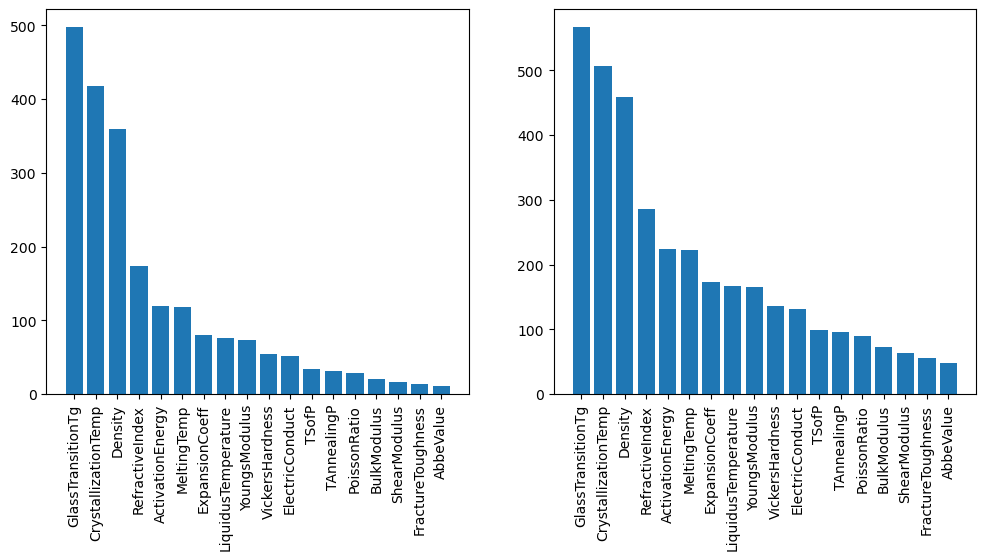

In [19]:
fig, ax = plt.subplots(figsize = [12,5], nrows=1, ncols=2)

ax[0].bar(df.prop_names, df.freq.values)
# ax[0].set_xticks(ticks = list(df.prop_names.values), rotation=90)
ax[0].tick_params(axis='x', labelrotation=90)

ax[1].bar(df.prop_names, df[f'{a}*x^{alpha}'])
ax[1].tick_params(axis='x', labelrotation=90)

# ax[1].set_xticks(ticks = list(df.prop_names.values), rotation=90)

plt.show()

In [20]:
import matplotlib.font_manager as fm
fm.fontManager.addfont('/home/scai/phd/aiz217586/.conda/envs/discomat/fonts/arial.ttf')

from new_plot import *
set_things()
set_font(weight='normal', family='Arial')

/home/scai/phd/aiz217586/.conda/envs/discomat/lib/python3.7/_collections_abc.py:841: MatplotlibDeprecationWarning: 
The animation.avconv_args rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = other[key]
/home/scai/phd/aiz217586/.conda/envs/discomat/lib/python3.7/_collections_abc.py:841: MatplotlibDeprecationWarning: 
The animation.avconv_path rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = other[key]
/home/scai/phd/aiz217586/.conda/envs/discomat/lib/python3.7/_collections_abc.py:841: MatplotlibDeprecationWarning: 
The animation.html_args rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = other[key]
/home/scai/phd/aiz217586/.conda/envs/discomat/lib/python3.7/_collections_abc.py:841: MatplotlibDeprecationWarning: 
The keymap.all_axes rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = oth

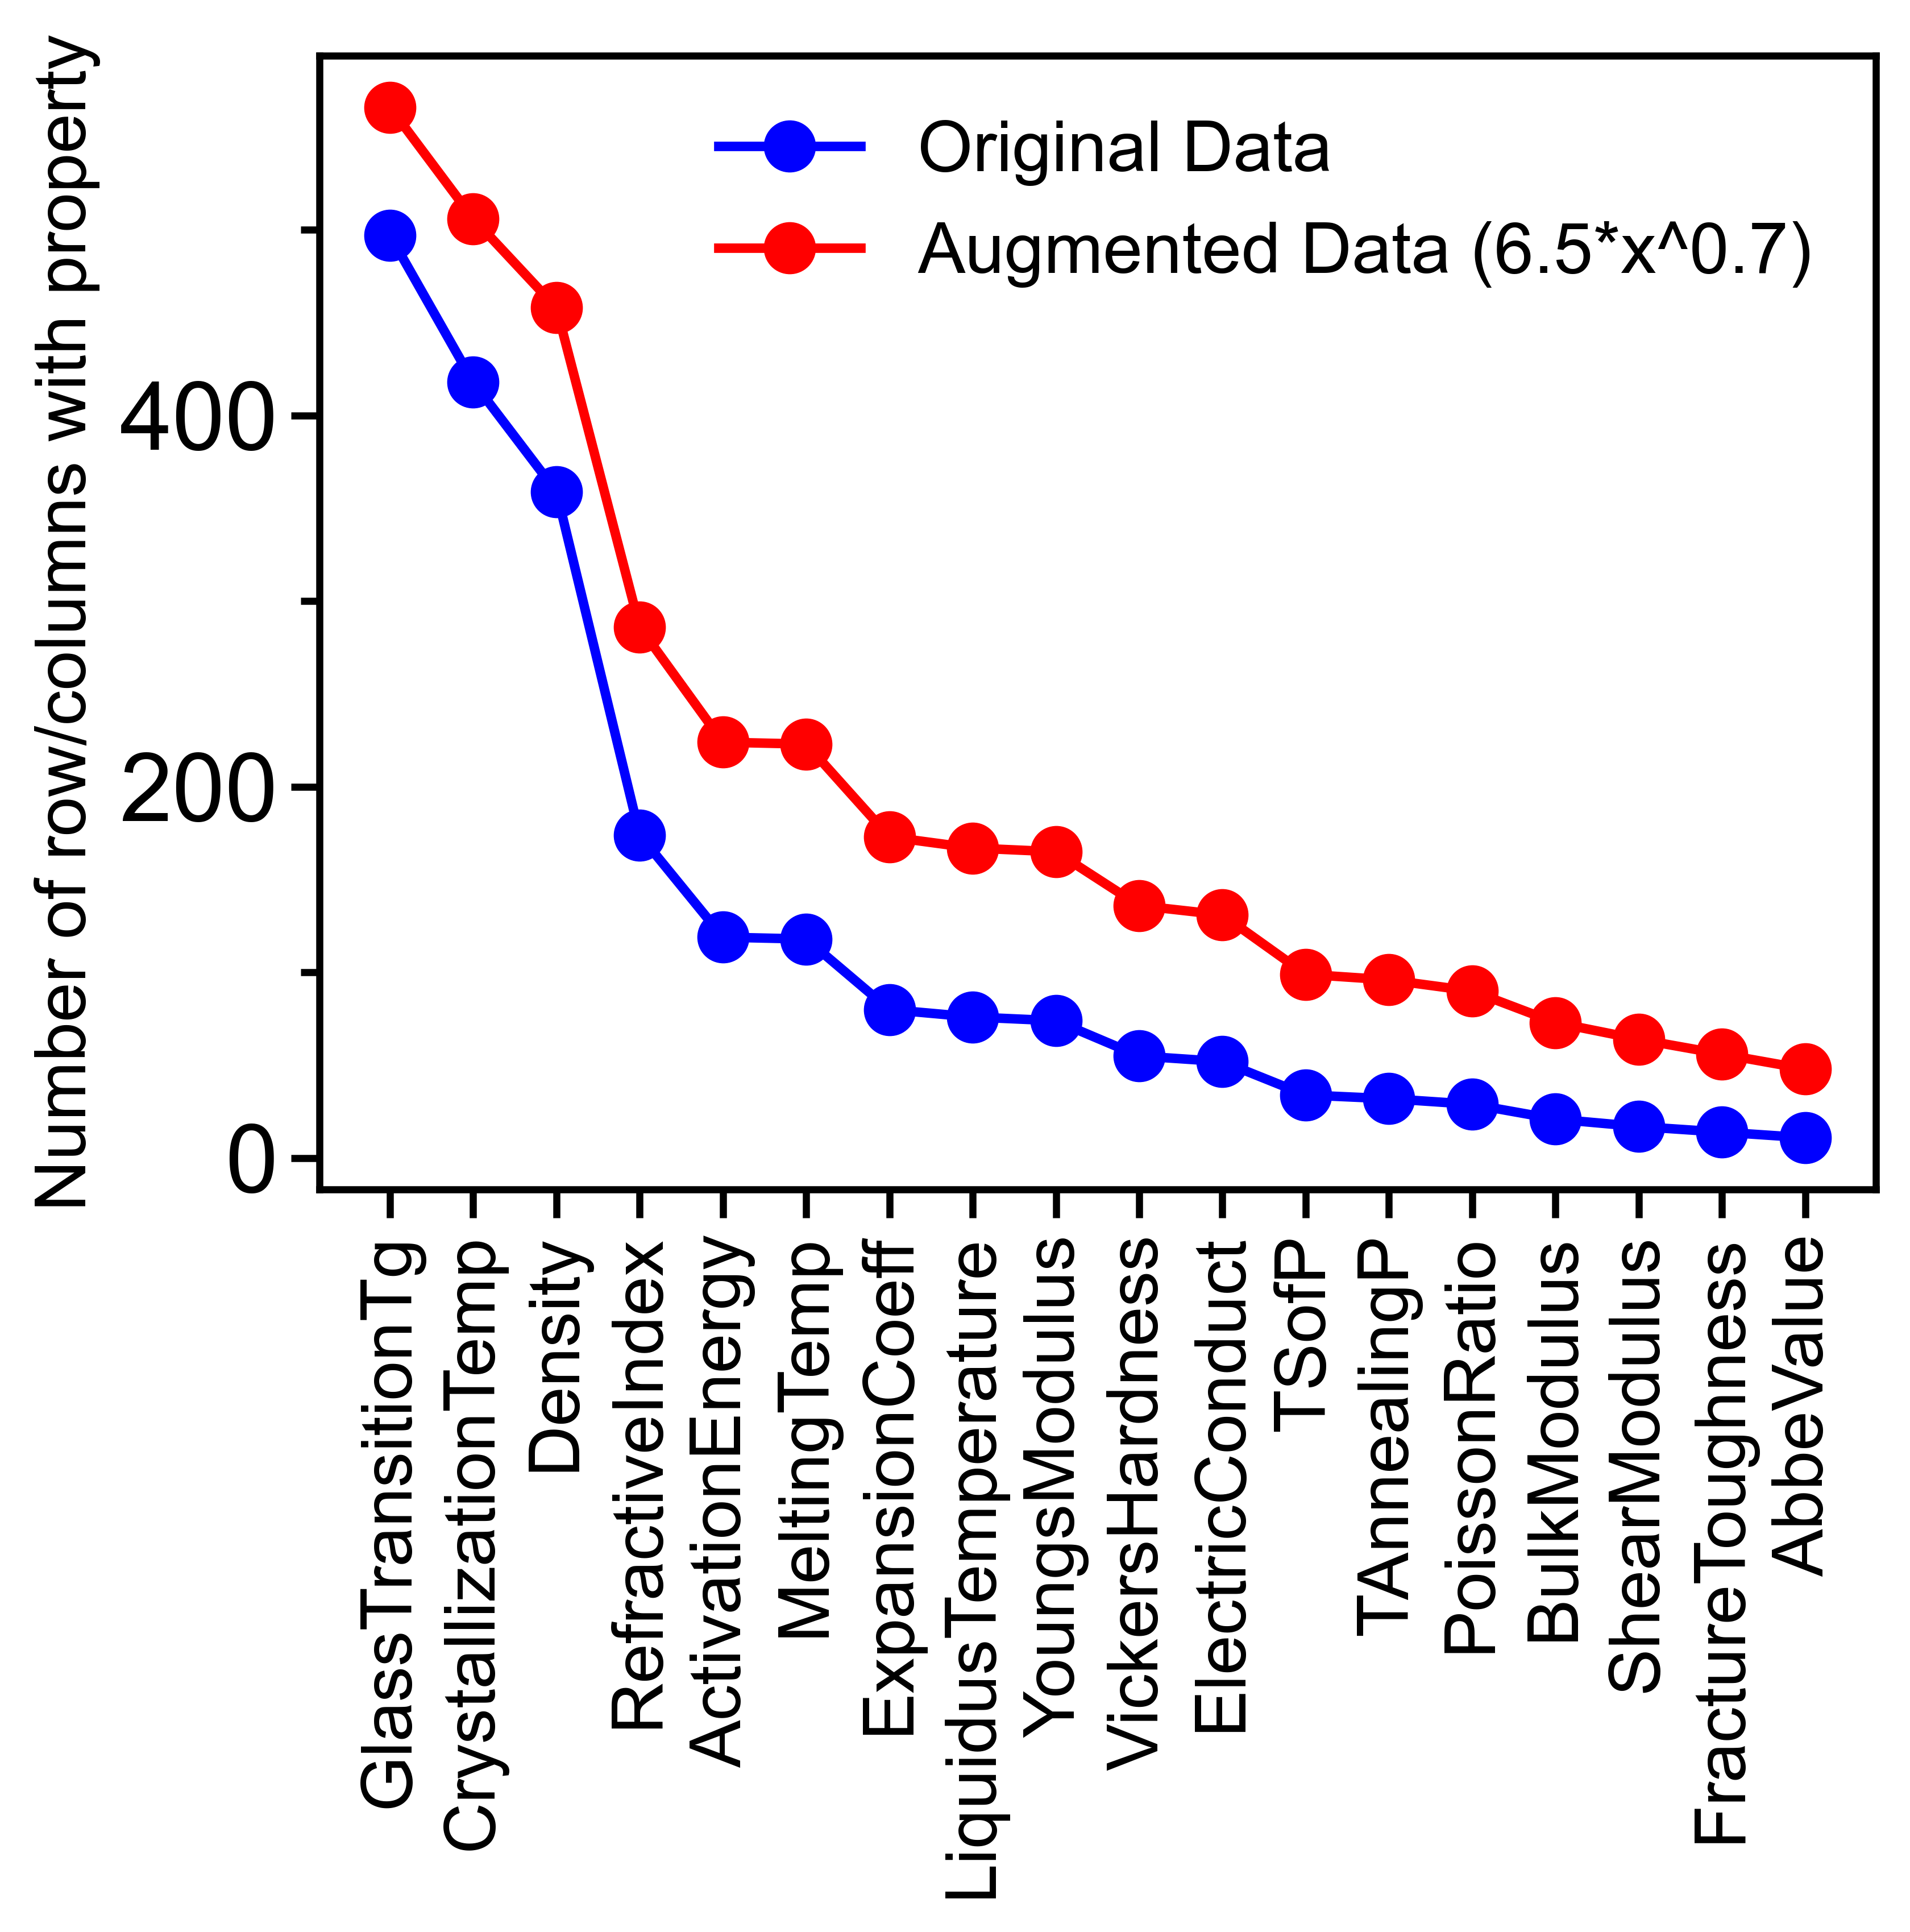

In [22]:
# Second plot
fig, ax = plt.subplots(figsize=[6, 6], dpi=600)

# Set ticks to appear outside
#     ax.tick_params(axis='both', direction='out', which='both')
# Set major tick length and remove minor ticks
ax.tick_params(axis='both', direction='out', length=6, which='major')  # Set major tick length
ax.tick_params(axis='y', direction='out', length=4, which='minor')  # Remove minor ticks
ax.tick_params(axis='x', direction='out', length=0, which='minor')  # Remove minor ticks

# Control ticks visibility
ax.tick_params(right=False,    # Remove right ticks
              top=False,       # Remove top ticks
              which='both')    # Apply to both major and minor ticks

# # Control ticks visibility
# ax.tick_params(bottom=False, which='minor') 

# Set ticks only on left and bottom
ax.tick_params(axis='x', which='both', bottom=True)
ax.tick_params(axis='y', which='both', left=True)


plt.plot(range(1,19), df.freq, '-o', label='Original Data')
plt.plot(range(1,19), df[f'{a}*x^{alpha}'], '-o', label='Augmented Data (6.5*x^0.7)')
plt.xticks(range(1,19), df.prop_names, rotation=90, fontsize=15)
plt.ylabel('Number of row/columns with property', fontsize=15)
plt.legend(fontsize=15)

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
plt.tight_layout()

# Save the plot before showing it
plt.savefig('augmented_plot.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [23]:
# # Second plot
# fig, ax = plt.subplots(figsize=[6, 6], dpi=600)  # Add this line
# plt.plot(range(1,19), df.freq, '-o', label='original')
# plt.plot(range(1,19), df[f'{a}*x^{alpha}'], '-o', label='augmented (6.5*x^0.7)')
# plt.xticks(range(1,19), df.prop_names, rotation=90, fontsize=15)  # Modified line
# plt.ylabel('Number of row/columns with property', fontsize=15)  # Modified line
# plt.legend(fontsize=15)  # Modified line

In [24]:
fig.patch.set_alpha(0.0)  # Add this line for transparent background
ax.patch.set_alpha(0.0)  # Add this line for transparent background
plt.tight_layout()  # Add this line to prevent label cutoff
plt.show()

<Figure size 432x432 with 0 Axes>

In [25]:
# plt.plot(range(1,20), df.freq, '-o', label='original')
# plt.plot(range(1,20), df[f'{a}*x^{alpha}'], '-o', label='augmented (6.5*x^0.7)')

# # for i in range(19):
# #     plt.text(i, df.freq.values[i]-20, df.freq.values[i])
# #     plt.text(i+3, df.freq.values[i]+15, df.freq.values[i])

# # plt.xlim(-2,20)
# plt.xticks(range(1,20), df.prop_names, rotation=90)
# plt.ylabel('Number of row/columns with property')
# plt.legend()

In [26]:
#convert df to dict
aug_dict = df.to_dict(orient='list')
aug_dict['new_freq'] = aug_dict['10*x^0.65']
del aug_dict['10*x^0.65']
aug_dict

{'prop_names': ['GlassTransitionTg',
  'CrystallizationTemp',
  'Density',
  'RefractiveIndex',
  'ActivationEnergy',
  'MeltingTemp',
  'ExpansionCoeff',
  'LiquidusTemperature',
  'YoungsModulus',
  'VickersHardness',
  'ElectricConduct',
  'TSofP',
  'TAnnealingP',
  'PoissonRatio',
  'BulkModulus',
  'ShearModulus',
  'FractureToughness',
  'AbbeValue'],
 'freq': [497,
  418,
  359,
  174,
  119,
  118,
  80,
  76,
  74,
  55,
  52,
  34,
  32,
  29,
  21,
  17,
  14,
  11],
 'prop_id': [5, 13, 4, 6, 22, 14, 19, 20, 8, 10, 15, 17, 18, 11, 21, 9, 12, 7],
 'friend_id': [[13, 20, 17, 18],
  [5, 20, 17, 18],
  [8],
  [7],
  [5],
  [5, 13, 20, 17, 18],
  [13, 5, 14, 20],
  [5, 13, 17, 18],
  [5, 13, 4, 6, 19, 20, 10, 21, 9, 12, 11],
  [5, 20, 13, 6, 4, 8, 21, 9, 12, 7],
  [5, 13, 4, 6],
  [5, 13, 18, 14],
  [5, 13, 17, 14],
  [4, 19, 8, 10, 21, 9, 12],
  [4, 19, 8, 10, 9, 11, 12],
  [4, 19, 8, 10, 11, 12, 21],
  [4, 19, 8, 10, 11, 9, 21],
  [6]],
 'new_freq': [566.0,
  506.0,
  458.0,
 

In [27]:
pickle.dump(aug_dict, open('../data/aug_dict.pkl', 'wb'))

In [28]:
# dummy = [1,2,3,4]
# dummy[dfreq.index(4)] = 0

In [29]:
# dummy

<h2>ONLY FOR ABBE

In [30]:

for idx, table in enumerate(data):
    if table['prop_table']:
        if 7 in table['row_label'] + table['col_label']:
            
            row = table['row_label']
            col = table['col_label']
            
            if 7 in col:
                coldata = table['act_table'][0][col.index(7)]
                
                if '(' in coldata and ')' in coldata and '/s' in coldata:
                    print(coldata)
                    col[col.index(7)] = 0
            if 7 in row:
                rowdata = table['act_table'][row.index(7)][0]
                if '(' in rowdata and ')' in rowdata and '/s' in rowdata:
                    print(rowdata)
                    row[row.index(7)] = 0
            # if 7 in col:
            #     col[col.index[7]] = 0    
            # display(pd.DataFrame(table['act_table']))

v d (cm/s)
V D (+-60 m/s)


In [31]:
import pickle
with open('../data/new_train_prop_data_abbe_changed.pkl','wb') as f:
    pickle.dump(data, f)
f.close()